# Qiskit Getting Started: Circuit, Sampler, and Estimator Primitives

This notebook demonstrates how to:
- Initialize quantum circuits with Qiskit
- Use the Sampler primitive for measuring quantum circuits
- Use the Estimator primitive for observable expectation value estimation
- Perform test examples on both Sampler and Estimator

Qiskit is an open-source quantum computing SDK from IBM, designed for algorithm development, education, and research on real quantum devices and simulators.


In [7]:
# Installation
# Run the following in a notebook cell to install Qiskit if needed:
# In Jupyter use: 
#     pip install qiskit
# In Google Colab use: 
    # !pip install qiskit
# Skip if already installed.

## Installation
Run the following command to install Qiskit if you have not already:

In Jupyter:

pip install qiskit

(If you run in Google Colab, include the exclamation mark: `!pip install qiskit`. Skip if already installed.)

## 1. Circuit Initialization Example
Let's create a 2-qubit quantum circuit that prepares a Bell state. We'll visualize it using Qiskit's built-in drawing tools.

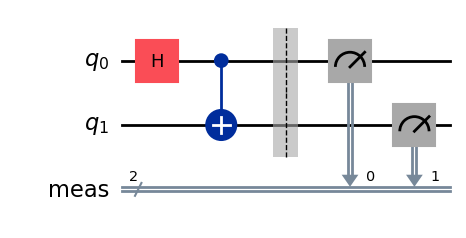

In [8]:
from qiskit import QuantumCircuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# In a Jupyter notebook this will render a matplotlib drawing (requires matplotlib installed)
qc.draw('mpl')

## 2. Using the Sampler Primitive
The Sampler allows us to estimate the measurement output probabilities for a given quantum circuit. Here, we'll sample results from a Bell state circuit.

In [9]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from collections import Counter

# Backend setup
backend = AerSimulator()

# Create Bell circuit
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

# Transpile to ISA circuit (using preset pass manager)
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(bell)

print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")

# Initialize Sampler primitive in 'backend' mode
sampler = Sampler(mode=backend)

print("Using sampler: SamplerV2 (AerSimulator)")

# Run the job & get results
job = sampler.run([(isa_circuit, None)], shots=1024)
result = job.result()

for i, pub_result in enumerate(result):
    bitstrings = pub_result.data.meas.get_bitstrings()
    counts = Counter(bitstrings)
    print(f"Circuit {i} counts: {counts}")
    print(f"'00': {counts.get('00', 0)}, '11': {counts.get('11', 0)}")


>>> Circuit ops (ISA): OrderedDict([('measure', 2), ('h', 1), ('cx', 1), ('barrier', 1)])
Using sampler: SamplerV2 (AerSimulator)
Circuit 0 counts: Counter({'11': 523, '00': 501})
'00': 501, '11': 523


## 3. Using the Estimator Primitive

The Estimator computes expectation values of observables on quantum circuits. We'll estimate ⟨Z⟩ for a simple superposition state |+⟩.

In [10]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager

# Setup simulator backend
backend = AerSimulator()

# Build your quantum circuit
circuit = QuantumCircuit(1)
circuit.h(0)  # prepares |+>

# Observable
op = SparsePauliOp('X')

# Transpile the circuit for the backend's ISA
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(circuit)

print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")

# If your observable layout needs to match (multi-qubit), apply layout
# For 1 qubit, it's not required; for general case (docs):
# isa_op = op.apply_layout(isa_circuit.layout) 

isa_op = op  # Here it's safe for 1 qubit

# Initialize EstimatorV2 in backend mode (docs recommend mode=backend)
estimator = Estimator(mode=backend)
estimator_name = 'EstimatorV2 (AerSimulator)'

print(f"Using estimator: {estimator_name}")

# Run (circuit, observable) as primitive unified bloc tuple
job = estimator.run([(isa_circuit, isa_op, None)])
res = job.result()

# PrimitiveResult is returned; extract expectation value(s)
for i, pub_result in enumerate(res):
    print(f"Estimator PUB {i} value(s):", pub_result.data.evs)
    print(f"Metadata:", pub_result.metadata)


>>> Circuit ops (ISA): OrderedDict([('h', 1)])
Using estimator: EstimatorV2 (AerSimulator)
Estimator PUB 0 value(s): 1.0
Metadata: {'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}}


## 4. Test Example: VQE-style Estimation

We scan a parameter θ in a single-qubit rotation circuit and plot the expectation value ⟨Z⟩ as a function of θ using the Estimator primitive.

Using EstimatorV2 (AerSimulator) for the sweep


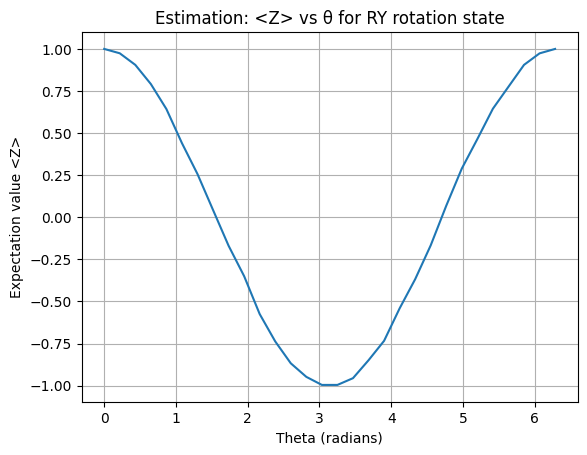

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit.transpiler import generate_preset_pass_manager

# Simulator backend
backend_sim = AerSimulator()
print('Using EstimatorV2 (AerSimulator) for the sweep')

# Parameterized circuit
theta = Parameter('θ')
var_circuit = QuantumCircuit(1)
var_circuit.ry(theta, 0)
observable = SparsePauliOp('Z')

# Transpile to backend's instruction set architecture (ISA)
pm = generate_preset_pass_manager(optimization_level=1, backend=backend_sim)
isa_circuit = pm.run(var_circuit)

# EstimatorV2 primitive in backend mode
estimator = Estimator(mode=backend_sim)

angles = np.linspace(0, 2 * np.pi, 30)
exp_vals = []
for angle in angles:
    param_values = [angle]  # wrap in a list for the PUB format
    job = estimator.run([(isa_circuit, observable, param_values)])
    res = job.result()
    pub_result = res[0]
    # pub_result.data.evs is a 0-d array (scalar), so use .item()
    exp_vals.append(pub_result.data.evs.item())

plt.plot(angles, exp_vals)
plt.xlabel('Theta (radians)')
plt.ylabel('Expectation value <Z>')
plt.title('Estimation: <Z> vs θ for RY rotation state')
plt.grid(True)
plt.show()


----
**References:**
- https://qiskit.org/documentation/apidoc/primitives.html
- https://qiskit.org/textbook/

Feel free to experiment with other circuits and observables, or extend this notebook with your custom quantum tasks!

### Exercise 1 — Prepare a GHZ State (incomplete)
Create a 3-qubit GHZ state (|000> + |111>)/√2 and verify the result using the sampler or a statevector sampler.

Task (fill the TODOs in the code cell):
- Add the missing entangling gates to prepare GHZ.
- Run the sampler and explain why the sampler output shows only the |000> and |111> outcomes.

In [5]:
# Exercise 1 — GHZ state (student exercise)
# Goal: prepare the 3-qubit GHZ state (|000> + |111>)/sqrt(2) and inspect measurement outcomes.
# TODO: finish the circuit by adding the required entangling gates (CNOTs).
from qiskit import QuantumCircuit

# Build an empty GHZ circuit skeleton
qc = QuantumCircuit(3)
qc.h(0)
# TODO: add two CNOT gates to entangle qubit 0 with qubits 1 and 2
# e.g. qc.cx(0, 1)
# e.g. qc.cx(0, 2)

# Add measurements (students should keep these)
qc.measure_all()

# Run skeleton: completes only after students fill TODOs
try:
    job = sampler.run([qc], shots=1024)
    res = job.result()
    # Student task: inspect 'res' and print the field that contains bitstrings/probabilities
    print('Run completed — inspect res in your environment (e.g., res[0].data.meas)')
except NameError:
    print('Sampler not defined — run the Sampler cell first')

Run completed — inspect res in your environment (e.g., res[0].data.meas)


### Exercise 2 — Measure in the X basis (incomplete)
Prepare the |+> state and modify the circuit so the measurement is effectively performed in the X basis. Leave one step for students to fill in.

Task (fill the TODOs in the code cell):
- Insert the single gate required to rotate the X basis into the Z basis before measurement.
- Run the sampler and explain how the results correspond to measuring in X.

In [6]:
# Exercise 2 — Measure in the X basis (student exercise)
# Goal: prepare |+> and perform a measurement in the X basis by rotating the basis before measurement.
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.h(0)  # prepares |+>
# TODO: insert the single-qubit gate that maps X eigenstates to Z eigenstates so a Z measurement reports X outcomes
# Hint: which gate maps the X basis to the Z basis? (apply it before measurement)

qc.measure_all()


Run completed — inspect res (e.g. res[0].data.meas or res[0].data.meas.get_bitstrings())


### Exercise 3 — Change the observable (incomplete)
In the VQE sweep example we estimated ⟨Z⟩. Modify the example to estimate ⟨X⟩ instead and re-run the sweep to observe the different expectation curve.

Task (fill the TODOs in the code cell):
- Replace the observable from Z to X (SparsePauliOp('X')).
- Re-run the sweep and briefly describe how the curve changes.

In [ ]:
# Exercise 3 stub — change observable to X (incomplete)
# TODO: In the VQE cell above, replace the observable definition with:
#   observable = SparsePauliOp('X')
# Then re-run the VQE sweep cell and compare the resulting plot with the original Z observable.

print('Exercise: replace the observable = SparsePauliOp("Z") with SparsePauliOp("X") in the VQE cell and re-run to see the difference.')